# SCAR DATA PREPROCESSING AND UNDERSTANDING

In [15]:
import pandas as pd
import ast
import json
import math
import re
from collections import Counter
import networkx as nx

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True



### `Dataset Exploration`

In [16]:
df_scar = pd.read_json('SCAR.json', lines=True)
df_scar.head()

,id,lang,system_a,system_b,mappings,system_a_domain,system_b_domain,system_a_background,system_b_background,Explanation
0,1,en,biological clock,clock,"[[changes, pointer], [state, time], [adjust, m...",Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...",[Changes correspond to pointers: In the biolog...
1,2,en,Biosphere,Library,"[[biology, books], [biodiversity, Book Type], ...",Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,[Biology corresponds to books: In the biospher...
2,3,en,Respiratory system,engine,"[[oxygen, fuel], [the lungs, combustion chambe...",Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,[Oxygen corresponds to fuel: In the respirator...
3,4,en,Spread of Pathogens,Spread of Fire,"[[pathogen, fire], [crowd, combustibles], [Pre...",Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,[Pathogens correspond to fire: in the transmis...
4,5,en,Gene editing,kirigami,"[[Gene, raw material], [CRISPR-Cas9 Technology...",Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,[Gene corresponds to raw materials: in gene ed...


In [17]:
# Display basic info
print("Dimensions=====")
print("Shape:", df_scar.shape)
print("Columns:", list(df_scar.columns))


Dimensions=====
Shape: (400, 10)
Columns: ['id', 'lang', 'system_a', 'system_b', 'mappings', 'system_a_domain', 'system_b_domain', 'system_a_background', 'system_b_background', 'Explanation']


In [18]:
# Helper function to count elements in sets/lists
def set_count(x):
    """
    Returns the count of elements in a collection (set, list, tuple, etc.)
    Returns 0 if the input is None or not a collection
    """
    if x is None:
        return 0
    try:
        return len(x)
    except TypeError:
        return 0


In [19]:
# if you loaded into df_scar
print("=== Dtypes ===")
print(df_scar.dtypes, "\n")

print("=== Missing values per column ===")
print(df_scar.isna().sum(), "\n")

print("=== Duplicates on subset ===")
subset_cols = [c for c in ["system_a","system_b","Explanation"] if c in df_scar.columns]
safe_subset = df_scar[subset_cols].astype(str)
print("Duplicates on subset (string-coerced):", safe_subset.duplicated().sum())


=== Dtypes ===
id                      int64
lang                   object
system_a               object
system_b               object
mappings               object
system_a_domain        object
system_b_domain        object
system_a_background    object
system_b_background    object
Explanation            object
dtype: object 

=== Missing values per column ===
id                     0
lang                   0
system_a               0
system_b               0
mappings               0
system_a_domain        0
system_b_domain        0
system_a_background    0
system_b_background    0
Explanation            0
dtype: int64 

=== Duplicates on subset ===
Duplicates on subset (string-coerced): 0


📝 Thankfully no missing values at all

In [20]:
def safe_parse_mappings(x):
    """
    mappings is shown like:
        [[changes, pointer], [state, time], [adjust, ...]]
    We'll try ast.literal_eval after making it JSON-like.
    """
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    s = str(x)

    # Try literal_eval first
    try:
        return ast.literal_eval(s)
    except Exception:
        pass

    # Make it JSON-ish: wrap bare tokens with quotes
    # e.g. [changes, pointer] -> ["changes", "pointer"]
    s2 = re.sub(r'\[([^\[\]]+)\]', lambda m: '[' + ', '.join(
        ['"{}"'.format(t.strip().strip('"').strip("'")) for t in m.group(1).split(',')]
    ) + ']', s)

    try:
        out = json.loads(s2.replace("'", '"'))
        if isinstance(out, list):
            return out
    except Exception:
        return []

    return []

# Parse mappings
df_scar["mappings_parsed"] = df_scar["mappings"].apply(safe_parse_mappings)
df_scar["explanation_parsed"] = df_scar["Explanation"].apply(safe_parse_mappings)

# Derived features
df_scar["mapping_count"] = df_scar["mappings_parsed"].apply(set_count)
df_scar["explanation_count"] = df_scar["explanation_parsed"].apply(set_count)

# Text length features
def word_count(s):
    if pd.isna(s): return 0
    return len(str(s).split())

df_scar["system_a_bg_wc"] = df_scar["system_a_background"].apply(word_count)
df_scar["system_b_bg_wc"] = df_scar["system_b_background"].apply(word_count)

# Quick describe
display(df_scar[["mapping_count", "explanation_count","system_a_bg_wc","system_a_bg_wc"]].describe())

,mapping_count,explanation_count,system_a_bg_wc,system_a_bg_wc
count,400.00000,400.000000,400.000000,400.000000
mean,4.04500,4.037500,148.900000,148.900000
std,1.87931,1.763198,44.622168,44.622168
min,2.00000,2.000000,26.000000,26.000000
25%,3.00000,3.000000,122.750000,122.750000
50%,3.00000,3.000000,142.000000,142.000000
75%,4.25000,5.000000,166.000000,166.000000
max,14.00000,14.000000,507.000000,507.000000


📝`Observations:`
- The Mappings could be from 2- 14!
- explanation is for each mapping also from 2-14, (but it seems not always aligned)
- The background for the source and target are from 26 words to 507 words!

In [21]:
df_scar.head(2)

,id,lang,system_a,system_b,mappings,system_a_domain,system_b_domain,system_a_background,system_b_background,Explanation,mappings_parsed,explanation_parsed,mapping_count,explanation_count,system_a_bg_wc,system_b_bg_wc
0,1,en,biological clock,clock,"[[changes, pointer], [state, time], [adjust, m...",Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...",[Changes correspond to pointers: In the biolog...,"[[changes, pointer], [state, time], [adjust, m...",[Changes correspond to pointers: In the biolog...,3,3,190,118
1,2,en,Biosphere,Library,"[[biology, books], [biodiversity, Book Type], ...",Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,[Biology corresponds to books: In the biospher...,"[[biology, books], [biodiversity, Book Type], ...",[Biology corresponds to books: In the biospher...,3,3,110,149


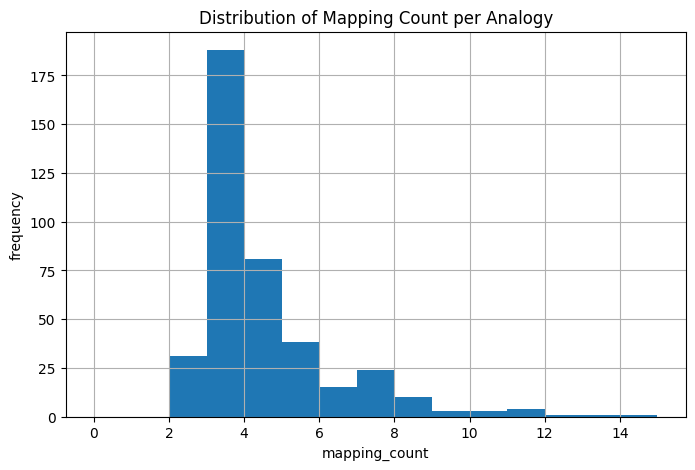

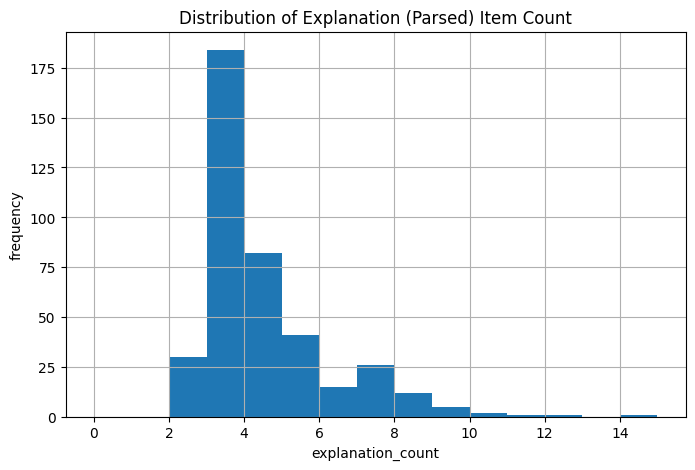

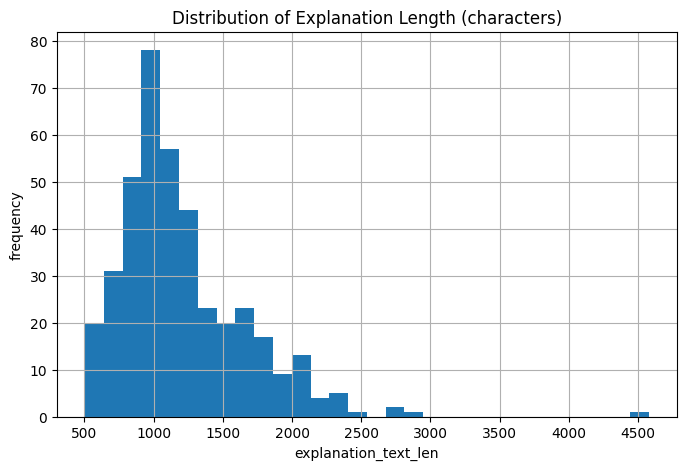

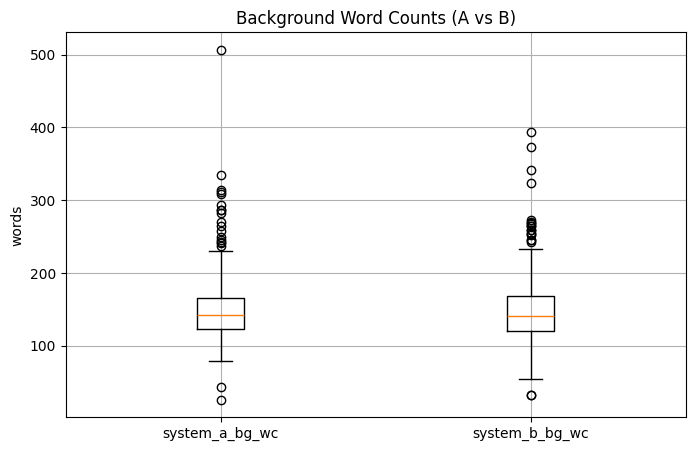

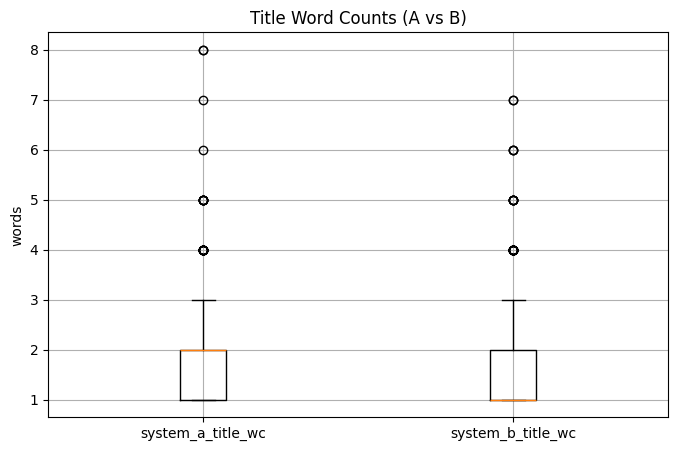

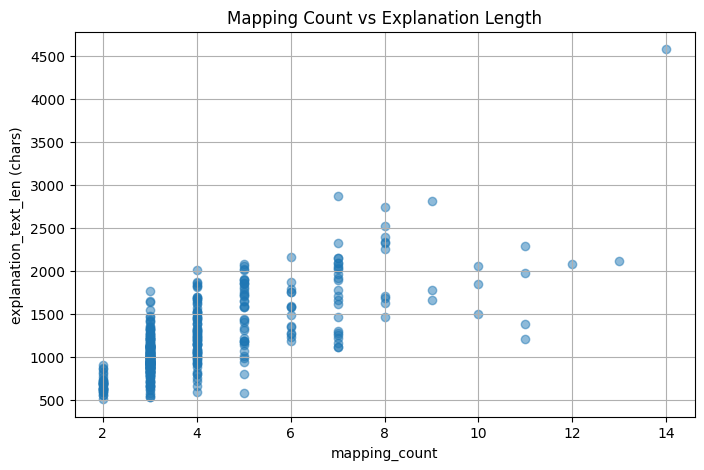

In [22]:
# Safety: create a text-length feature for the raw explanation text too
df_scar["explanation_text_len"] = df_scar["Explanation"].fillna("").astype(str).str.len()

# Titles word count (added here so this cell is self-contained)
def word_count(s):
    if pd.isna(s): return 0
    return len(str(s).split())

df_scar["system_a_title_wc"] = df_scar["system_a"].apply(word_count)
df_scar["system_b_title_wc"] = df_scar["system_b"].apply(word_count)

# --- Hist: mapping_count
plt.figure()
max_map = int(df_scar["mapping_count"].max()) if len(df_scar) else 0
bins = range(0, max_map + 2)
df_scar["mapping_count"].plot(kind="hist", bins=bins)
plt.title("Distribution of Mapping Count per Analogy")
plt.xlabel("mapping_count")
plt.ylabel("frequency")
plt.show()

# --- Hist: explanation_count (parsed list length)
plt.figure()
max_exp = int(df_scar["explanation_count"].max()) if len(df_scar) else 0
bins = range(0, max_exp + 2)
df_scar["explanation_count"].plot(kind="hist", bins=bins)
plt.title("Distribution of Explanation (Parsed) Item Count")
plt.xlabel("explanation_count")
plt.ylabel("frequency")
plt.show()

# --- Hist: explanation_text_len (chars)
plt.figure()
df_scar["explanation_text_len"].plot(kind="hist", bins=30)
plt.title("Distribution of Explanation Length (characters)")
plt.xlabel("explanation_text_len")
plt.ylabel("frequency")
plt.show()

# --- Boxplots: background word counts A vs B
plt.figure()
plt.boxplot([df_scar["system_a_bg_wc"].dropna(),
             df_scar["system_b_bg_wc"].dropna()],
            labels=["system_a_bg_wc", "system_b_bg_wc"])
plt.title("Background Word Counts (A vs B)")
plt.ylabel("words")
plt.show()

# --- Boxplots: title word counts A vs B
plt.figure()
plt.boxplot([df_scar["system_a_title_wc"].dropna(),
             df_scar["system_b_title_wc"].dropna()],
            labels=["system_a_title_wc", "system_b_title_wc"])
plt.title("Title Word Counts (A vs B)")
plt.ylabel("words")
plt.show()

# --- Scatter: mapping_count vs explanation_text_len
plt.figure()
plt.scatter(df_scar["mapping_count"], df_scar["explanation_text_len"], alpha=0.5)
plt.title("Mapping Count vs Explanation Length")
plt.xlabel("mapping_count")
plt.ylabel("explanation_text_len (chars)")
plt.show()


Equal (on y=x): 387
Greater (mappings > explanations): 6
Less (mappings < explanations): 7


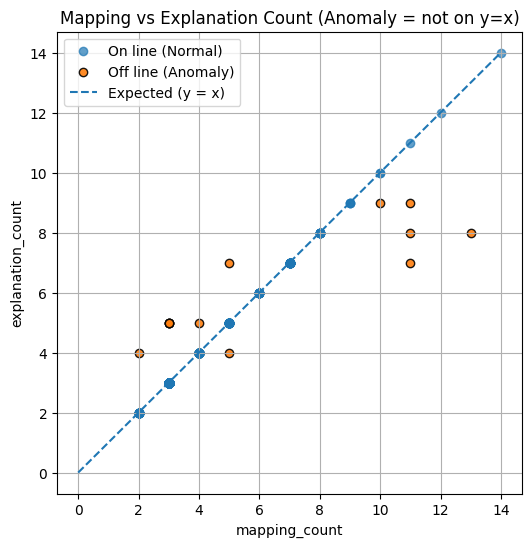

,id,system_a,system_b,mapping_count,explanation_count,abs_diff
317,318,war,business,13,8,5
286,287,battle,debate,11,7,4
303,304,journey,illness,11,8,3
52,53,blood circulation system,Water pipe system,3,5,2
84,85,Limit Modification System,Firewall,5,7,2
147,148,Cross Validation,Fishing,2,4,2
169,170,Option Pricing Model,Insurance Contract,3,5,2
238,239,British Constitutional Monarchy,German Constitutional Monarchy,3,5,2
311,312,journey,career,11,9,2
378,379,Two-dimensional Electron Gas,Checkers,3,5,2


In [23]:
# safety: ensure numeric and drop NaNs
x = pd.to_numeric(df_scar["mapping_count"], errors="coerce")
y = pd.to_numeric(df_scar["explanation_count"], errors="coerce")
valid = x.notna() & y.notna()
x = x[valid]; y = y[valid]
df_plot = df_scar.loc[valid].copy()

# equal / greater / less
eq_mask = (x == y)
gt_mask = (x >  y)
lt_mask = (x <  y)
print("Equal (on y=x):", int(eq_mask.sum()))
print("Greater (mappings > explanations):", int(gt_mask.sum()))
print("Less (mappings < explanations):", int(lt_mask.sum()))

# anomalies
anomaly_mask = ~eq_mask

# straight line
max_val = int(max(x.max(), y.max())) if len(x) else 0
line = np.arange(0, max_val + 1)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(x[eq_mask], y[eq_mask], alpha=0.7, label="On line (Normal)")
plt.scatter(x[anomaly_mask], y[anomaly_mask], alpha=0.9, edgecolors="black", label="Off line (Anomaly)")
plt.plot(line, line, linestyle="--", label="Expected (y = x)")
plt.title("Mapping vs Explanation Count (Anomaly = not on y=x)")
plt.xlabel("mapping_count"); plt.ylabel("explanation_count")
plt.grid(True); plt.legend()
plt.show()

# anomaly table
anom_tbl = (df_plot.loc[anomaly_mask, ["id","system_a","system_b","mapping_count","explanation_count"]]
            .assign(abs_diff=lambda d: (d.explanation_count - d.mapping_count).abs())
            .sort_values("abs_diff", ascending=False))
display(anom_tbl.head(20))


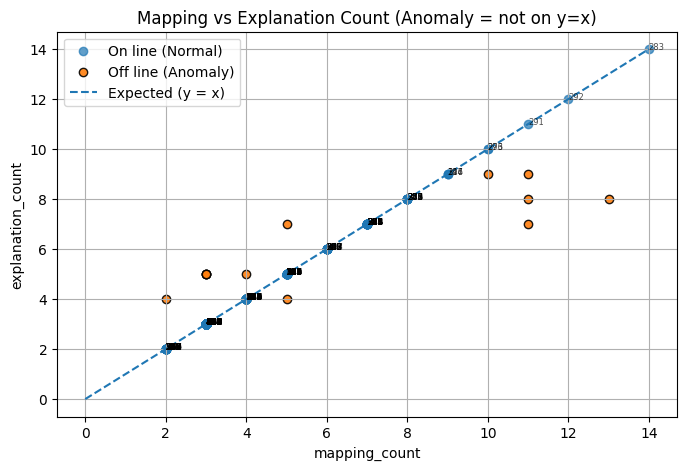

In [24]:
# scatter normal vs anomaly
plt.scatter(x[eq_mask], y[eq_mask], alpha=0.7, label="On line (Normal)")
plt.scatter(x[anomaly_mask], y[anomaly_mask], alpha=0.9,
            edgecolors="black", label="Off line (Anomaly)")

# only annotate normal (or whichever group you want labeled)
for xi, yi, id_ in zip(x[eq_mask], y[eq_mask], df_plot.loc[eq_mask, "id"]):
    plt.annotate(str(id_), (xi, yi),
                 fontsize=6, alpha=0.7)  # adjust params as you like

plt.plot(line, line, linestyle="--", label="Expected (y = x)")
plt.title("Mapping vs Explanation Count (Anomaly = not on y=x)")
plt.xlabel("mapping_count"); plt.ylabel("explanation_count")
plt.grid(True); plt.legend()
plt.show()


In [25]:
# Filter to rows where counts differ
misaligned = df_scar[df_scar["explanation_count"] != df_scar["mapping_count"]]

for i in range(len(misaligned)):
    # Take the first one
    print("Turn Number============================================", i)
    example = misaligned.iloc[i]

    print("=== ID ===")
    print(example["id"] if "id" in example else "(no id)")

    print("\n=== System A / B ===")
    print("A:", example["system_a"])
    print("B:", example["system_b"])

    print("\n=== Explanation ===")
    print(example["Explanation"])

    print("\n=== Mapping Count:", example["mapping_count"], "===")
    for i, m in enumerate(example["mappings_parsed"], start=1):
        print(f"{i}. {m}")

    print("\n=== Explanation Count:", example["explanation_count"], "===")
    for i, e in enumerate(example["explanation_parsed"], start=1):
        print(f"{i}. {e}")


Turn Number============================================ 0
=== ID ===
53

=== System A / B ===
A: blood circulation system
B: Water pipe system

=== Explanation ===
['Items: blood, water flow, heart, Pump, Blood vessel, pipeline', 'Translation:', 'Blood corresponds to water flow: Blood is the medium responsible for carrying oxygen, nutrients, etc. in the circulatory system. In the water pipe system, water flow is the medium for transporting water. Both are transport media in their respective systems.', 'Heart corresponds to Pump: The heart is the organ responsible for pumping blood in the circulatory system. In the water pipe system, the pump is responsible for pumping water. Both are pumping equipment in their respective systems.', 'Blood vessel corresponds to pipeline: Blood vessels are the channels for transporting blood in the circulatory system. In the water pipe system, pipelines are the channels for transporting water. Both are channels for transport media.']

=== Mapping Count: 

#### Fix the mismatching


📝 We have around 13 rows that dont have aligned explanations with the mapping of the concepts
- Sometimes the data skips explaining one mapping pair
- Sometimes the explanation is done in a list that has all pairs, but formated in a wrong way
- Sometimes the same source, has multiple targets, and they are correct
- sometimes there is more explanation because there is a randomly added output

,count_A
system_a_domain,
Biology,100
History,60
Physics,49
Computer,41
Chemical,37
Philosophy,31
Literature,23
Geography,19
Economy,13


,count_B
system_b_domain,
History,69
Philosophy,61
Biology,48
Engineering,45
Physics,44
Art,39
Geography,25
Literature,18
Economy,15


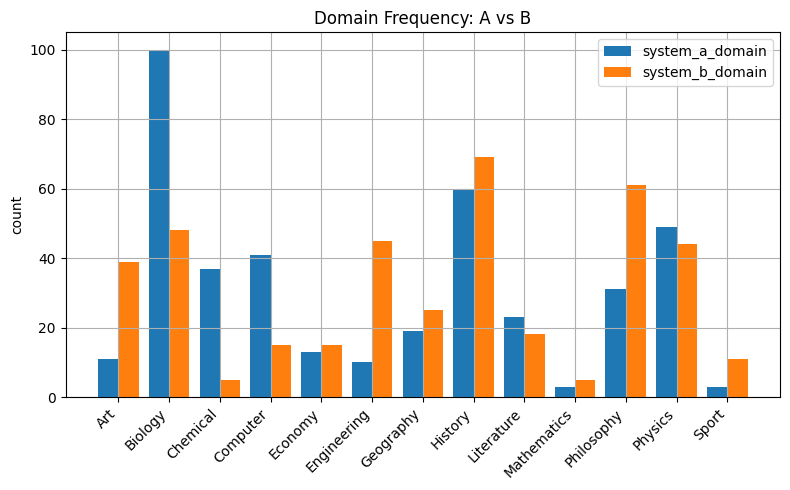

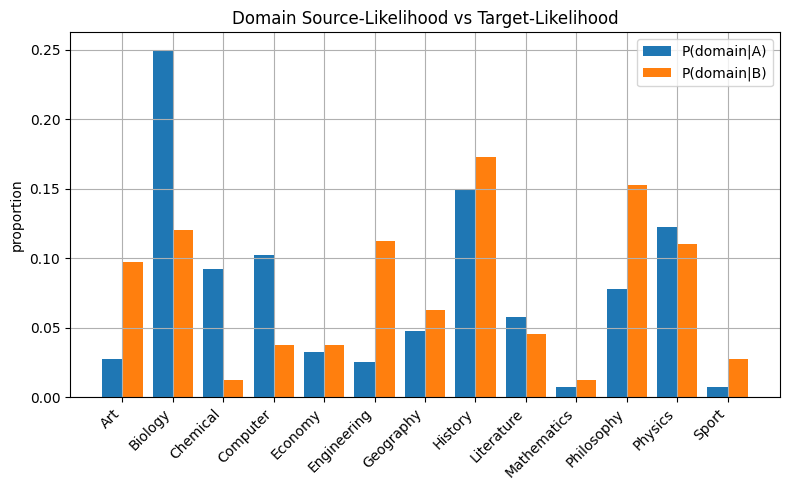

In [26]:
a_counts = df_scar["system_a_domain"].value_counts(dropna=False)
b_counts = df_scar["system_b_domain"].value_counts(dropna=False)

display(a_counts.to_frame("count_A"))
display(b_counts.to_frame("count_B"))

# Unified domain order
all_domains = sorted(
    set(a_counts.index.tolist()) | set(b_counts.index.tolist()),
    key=lambda x: "" if pd.isna(x) else str(x)
)

a_vals = [a_counts.get(d, 0) for d in all_domains]
b_vals = [b_counts.get(d, 0) for d in all_domains]

x = np.arange(len(all_domains))
w = 0.4

plt.figure(figsize=(max(8, len(all_domains)*0.6), 5))
plt.bar(x - w/2, a_vals, width=w, label="system_a_domain")
plt.bar(x + w/2, b_vals, width=w, label="system_b_domain")
plt.title("Domain Frequency: A vs B")
plt.xticks(x, [str(d) for d in all_domains], rotation=45, ha="right")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

# Proportions
total_A = sum(a_vals)
total_B = sum(b_vals)
a_prob = [v/total_A if total_A else 0 for v in a_vals]
b_prob = [v/total_B if total_B else 0 for v in b_vals]

plt.figure(figsize=(max(8, len(all_domains)*0.6), 5))
plt.bar(x - w/2, a_prob, width=w, label="P(domain|A)")
plt.bar(x + w/2, b_prob, width=w, label="P(domain|B)")
plt.title("Domain Source-Likelihood vs Target-Likelihood")
plt.xticks(x, [str(d) for d in all_domains], rotation=45, ha="right")
plt.ylabel("proportion")
plt.legend()
plt.tight_layout()
plt.show()


Caption: Relative frequency of each domain appearing as the source (System A) or target (System B) in the analogy dataset. Taller blue bars indicate domains more often used as the source; taller orange bars indicate domains more often used as the target.

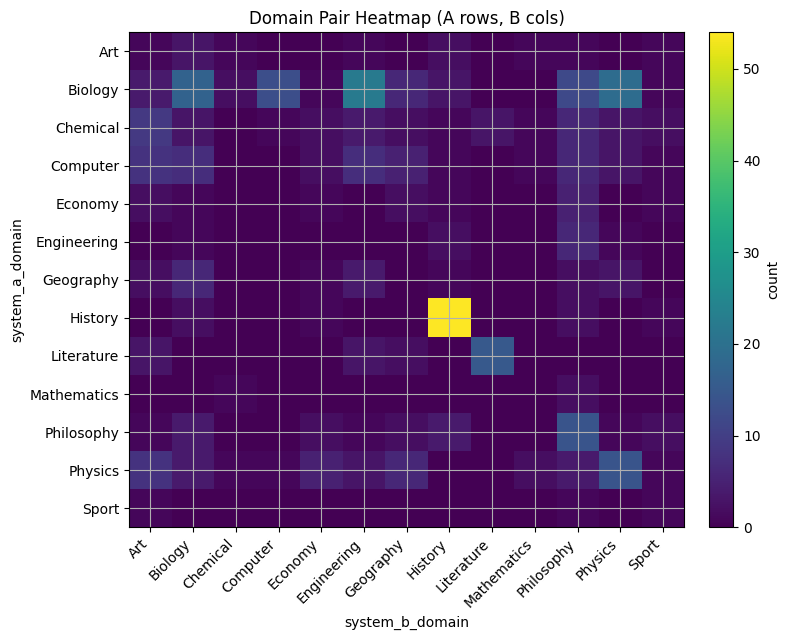

system_b_domain,Art,Biology,Chemical,Computer,Economy,Engineering,Geography,History,Literature,Mathematics,Philosophy,Physics,Sport
system_a_domain,,,,,,,,,,,,,
Art,1,3,1,0,0,1,0,2,0,1,1,0,1
Biology,4,17,2,13,1,22,6,3,0,0,12,19,1
Chemical,9,3,0,1,2,4,2,1,3,1,6,3,2
Computer,8,7,0,0,2,7,5,1,0,1,6,3,1
Economy,2,1,0,0,1,0,2,1,0,0,5,0,1
Engineering,0,1,0,0,0,0,0,2,0,0,6,1,0
Geography,2,6,0,0,1,4,0,1,0,0,2,3,0
History,0,2,0,0,1,0,0,54,0,0,2,0,1
Literature,3,0,0,0,0,3,2,0,15,0,0,0,0


In [27]:
# pivot table (counts)
heat = (
    df_scar.groupby(["system_a_domain", "system_b_domain"])
           .size()
           .unstack(fill_value=0)
)

plt.figure(figsize=(max(8, heat.shape[1]*0.6), max(6, heat.shape[0]*0.5)))
im = plt.imshow(heat.values, aspect="auto")
plt.title("Domain Pair Heatmap (A rows, B cols)")
plt.xlabel("system_b_domain")
plt.ylabel("system_a_domain")

plt.xticks(range(heat.shape[1]), heat.columns.astype(str), rotation=45, ha="right")
plt.yticks(range(heat.shape[0]), heat.index.astype(str))

plt.colorbar(im, fraction=0.046, pad=0.04, label="count")
plt.tight_layout()
plt.show()

display(heat.astype(int))


📝 The dataset has ALOT of times the source and target are from the same domain
- Biology - Literature - History - phylosiphy - physics


,domain,P_domain_as_A,P_domain_as_B,bias_A_minus_B
1,Biology,0.2500,0.1200,0.1300
2,Chemical,0.0925,0.0125,0.0800
3,Computer,0.1025,0.0375,0.0650
8,Literature,0.0575,0.0450,0.0125
11,Physics,0.1225,0.1100,0.0125
4,Economy,0.0325,0.0375,-0.0050
9,Mathematics,0.0075,0.0125,-0.0050
6,Geography,0.0475,0.0625,-0.0150
12,Sport,0.0075,0.0275,-0.0200
7,History,0.1500,0.1725,-0.0225


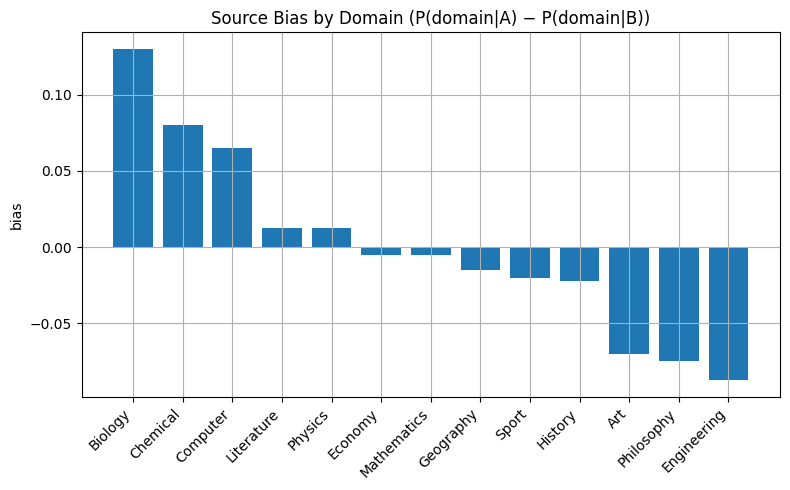

In [28]:
bias_df = pd.DataFrame({
    "domain": [str(d) for d in all_domains],
    "P_domain_as_A": a_prob,
    "P_domain_as_B": b_prob
})
bias_df["bias_A_minus_B"] = bias_df["P_domain_as_A"] - bias_df["P_domain_as_B"]
bias_df = bias_df.sort_values("bias_A_minus_B", ascending=False)

display(bias_df)

plt.figure(figsize=(max(8, len(bias_df)*0.6), 5))
plt.bar(range(len(bias_df)), bias_df["bias_A_minus_B"])
plt.xticks(range(len(bias_df)), bias_df["domain"], rotation=45, ha="right")
plt.title("Source Bias by Domain (P(domain|A) − P(domain|B))")
plt.ylabel("bias")
plt.tight_layout()
plt.show()


In [29]:
from IPython.display import display

def show_examples(domain_A=None, domain_B=None, n=3):
    q = df_scar.copy()
    if domain_A is not None:
        q = q[q["system_a_domain"] == domain_A]
    if domain_B is not None:
        q = q[q["system_b_domain"] == domain_B]
    subset = q.sample(min(n, len(q))) if len(q) else q

    cols = ["id", "system_a", "system_b", "mappings_parsed", "mapping_count",
            "explanation_parsed", "explanation_count", "Explanation"]
    cols = [c for c in cols if c in subset.columns]
    display(subset[cols])

# Example usage:
show_examples(domain_A="Biology", domain_B="Engineering", n=3)


,id,system_a,system_b,mappings_parsed,mapping_count,explanation_parsed,explanation_count,Explanation
56,57,The Evolution of Viruses,The Production Line of a Car Factory,"[[Virus, raw material], [Mutations, renew], [N...",3,[Virus corresponds to raw material: A virus is...,3,[Virus corresponds to raw material: A virus is...
0,1,biological clock,clock,"[[changes, pointer], [state, time], [adjust, m...",3,[Changes correspond to pointers: In the biolog...,3,[Changes correspond to pointers: In the biolog...
43,44,Endocrine System,Regulator,"[[endocrine organs, controller], [hormone, Reg...",2,[Endocrine organs correspond to controllers: E...,2,[Endocrine organs correspond to controllers: E...


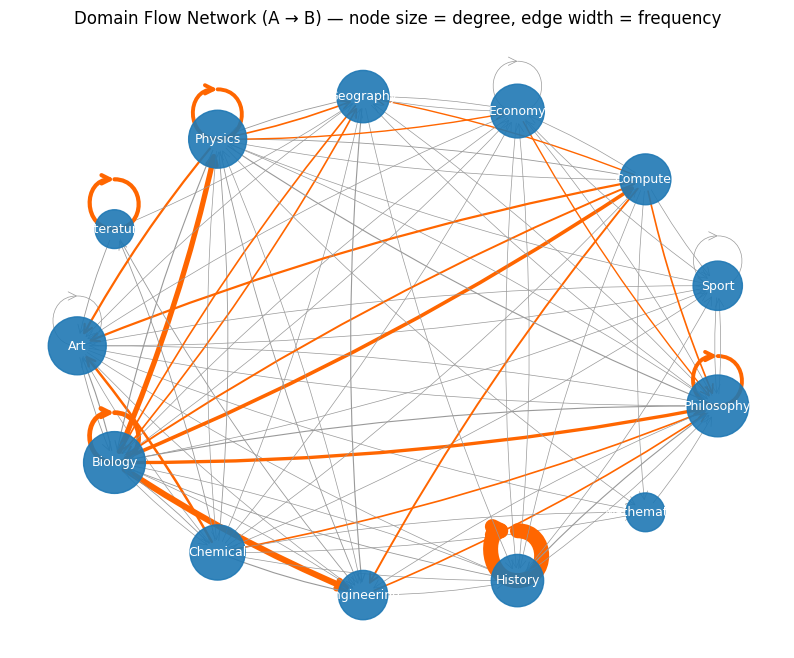

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# build weighted edges from your dataframe
edge_df = (
    df_scar.groupby(["system_a_domain", "system_b_domain"])
           .size()
           .reset_index(name="weight")
)

# create graph
G = nx.DiGraph()
for _, row in edge_df.iterrows():
    a = str(row["system_a_domain"])
    b = str(row["system_b_domain"])
    w = int(row["weight"])
    if w > 0:
        G.add_edge(a, b, weight=w)

# node size = total degree
node_sizes = [300 + 80*(G.in_degree(n)+G.out_degree(n)) for n in G.nodes()]
# edge widths = weight
edge_widths = [max(0.5, w["weight"]*0.2) for _,_,w in G.edges(data=True)]
# edge colors
edge_colors = ["#999999" if w["weight"]<5 else "#ff6600" for _,_,w in G.edges(data=True)]

# pick a layout: shell/circular for clarity
pos = nx.shell_layout(G)  # or nx.circular_layout(G)

plt.figure(figsize=(10,8))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#1f78b4", alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white")

nx.draw_networkx_edges(G, pos,
                       arrows=True,
                       arrowstyle="->",
                       arrowsize=15,
                       width=edge_widths,
                       edge_color=edge_colors,
                       connectionstyle="arc3,rad=0.05")  # small curvature

plt.title("Domain Flow Network (A → B) — node size = degree, edge width = frequency")
plt.axis("off")
plt.show()


## SUMMARY:


`Dataset Overview`
- Size: 400 analogies
- Structure: Each row contains two systems (source A and target B) with mappings and explanations between their concepts
- Data Quality: No missing values, no duplicates - clean dataset

`Key Findings`
1. Mapping & Explanation Counts
    - Mapping pairs range: 2-14 per analogy
    - Explanation counts: Also 2-14, but not always aligned with mappings
    - Alignment Issue: Only 13 rows (~3.25%) have misaligned mappings and explanations
    - 387 rows have equal counts (normal)
    - 6 rows have more mappings than explanations
    - 7 rows have more explanations than mappings
2. Background Context Lengths
    - System A & B background text: 26-507 words, Considerable variation in how much context is provided
3. Domain Distribution Patterns
    - Strong within-domain bias: Many analogies map concepts within the same domain
        - Most frequently paired domains:
            - Biology ↔ Biology
            - Literature ↔ Literature
            - History ↔ History
            - Philosophy ↔ Philosophy
            - Physics ↔ Physics
4. Source vs Target Bias
    - Some domains are more commonly used as sources (System A)
    - Others more commonly used as targets (System B)
    - The domain flow network shows clear directional preferences
5. Data Quality Issues Identified
    - Some explanations skip mapping pairs
    - Some explanations are formatted incorrectly (list formatting issues)
    - Sometimes one source has multiple valid targets
    - Occasionally random/duplicate outputs appear in explanations

In [31]:
import pandas as pd
import ast, re, json

# --- 1. load your raw df (replace path accordingly)
# df_scar = pd.read_csv("your_file.csv")

# --- 2. parser for mappings & explanation
def safe_parse(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    s = str(x)
    try:
        return ast.literal_eval(s)
    except Exception:
        pass
    s2 = re.sub(r'\[([^\[\]]+)\]', lambda m: '[' + ', '.join(
        ['"{}"'.format(t.strip().strip('"').strip("'")) for t in m.group(1).split(',')]
    ) + ']', s)
    try:
        out = json.loads(s2.replace("'", '"'))
        if isinstance(out, list):
            return out
    except Exception:
        return []
    return []

# --- 3. create parsed + counts
df_scar["mappings_parsed"] = df_scar["mappings"].apply(safe_parse)
df_scar["explanation_parsed"] = df_scar["Explanation"].apply(safe_parse)
df_scar["mapping_count"] = df_scar["mappings_parsed"].apply(set_count)
df_scar["explanation_count"] = df_scar["explanation_parsed"].apply(set_count)

# --- 4. word count helpers
def word_count(s):
    if pd.isna(s): return 0
    return len(str(s).split())

df_scar["system_a_bg_wc"] = df_scar["system_a_background"].apply(word_count)
df_scar["system_b_bg_wc"] = df_scar["system_b_background"].apply(word_count)

# --- 5. now select only what you need for experiments
exp_cols = [
    "id",
    "system_a","system_b",
    "system_a_domain","system_b_domain",
    "system_a_background","system_b_background",
    "mappings_parsed","mapping_count",
    "explanation_parsed","explanation_count",
    "system_a_bg_wc","system_b_bg_wc"
]
exp_cols = [c for c in exp_cols if c in df_scar.columns]  # in case some missing

df_exp = df_scar[exp_cols].copy()

# --- 6. optional: filter misaligned only
# df_exp = df_exp[df_exp["mapping_count"] != df_exp["explanation_count"]]

# --- 7. see the result
display(df_exp.head())

# # (optional) save for later use
df_exp.to_csv("SCAR_cleaned.csv", index=False)


,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,explanation_count,system_a_bg_wc,system_b_bg_wc
0,1,biological clock,clock,Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...","[[changes, pointer], [state, time], [adjust, m...",3,[Changes correspond to pointers: In the biolog...,3,190,118
1,2,Biosphere,Library,Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,"[[biology, books], [biodiversity, Book Type], ...",3,[Biology corresponds to books: In the biospher...,3,110,149
2,3,Respiratory system,engine,Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,"[[oxygen, fuel], [the lungs, combustion chambe...",3,[Oxygen corresponds to fuel: In the respirator...,3,131,143
3,4,Spread of Pathogens,Spread of Fire,Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,"[[pathogen, fire], [crowd, combustibles], [Pre...",3,[Pathogens correspond to fire: in the transmis...,3,127,170
4,5,Gene editing,kirigami,Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,"[[Gene, raw material], [CRISPR-Cas9 Technology...",3,[Gene corresponds to raw materials: in gene ed...,3,133,130


### After Manually Cleaning
We only have 3 mappings that arent aligned because they are one -to- many mapping

In [32]:
df_scar_edited = pd.read_csv('SCAR_cleaned_manually.csv')
df_scar_edited.head()

,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,explanation_count,system_a_bg_wc,system_b_bg_wc
0,1,biological clock,clock,Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...","[['changes', 'pointer'], ['state', 'time'], ['...",3,['Changes correspond to pointers: In the biolo...,3,190,118
1,2,Biosphere,Library,Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,"[['biology', 'books'], ['biodiversity', 'Book ...",3,"[""Biology corresponds to books: In the biosphe...",3,110,149
2,3,Respiratory system,engine,Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,"[['oxygen', 'fuel'], ['the lungs', 'combustion...",3,['Oxygen corresponds to fuel: In the respirato...,3,131,143
3,4,Spread of Pathogens,Spread of Fire,Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,"[['pathogen', 'fire'], ['crowd', 'combustibles...",3,['Pathogens correspond to fire: in the transmi...,3,127,170
4,5,Gene editing,kirigami,Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,"[['Gene', 'raw material'], ['CRISPR-Cas9 Techn...",3,['Gene corresponds to raw materials: in gene e...,3,133,130


In [33]:
# update the number of mappings and explanations
import ast

df_scar_edited["explanation_count"] = df_scar_edited["explanation_parsed"].apply(
    lambda x: len(ast.literal_eval(x)) if isinstance(x, str) else len(x)
)
df_scar_edited["mapping_count"] = df_scar_edited["mappings_parsed"].apply(
    lambda x: len(ast.literal_eval(x)) if isinstance(x, str) else len(x)
)

In [34]:
df_scar_edited.head()

,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,explanation_count,system_a_bg_wc,system_b_bg_wc
0,1,biological clock,clock,Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...","[['changes', 'pointer'], ['state', 'time'], ['...",3,['Changes correspond to pointers: In the biolo...,3,190,118
1,2,Biosphere,Library,Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,"[['biology', 'books'], ['biodiversity', 'Book ...",3,"[""Biology corresponds to books: In the biosphe...",3,110,149
2,3,Respiratory system,engine,Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,"[['oxygen', 'fuel'], ['the lungs', 'combustion...",3,['Oxygen corresponds to fuel: In the respirato...,3,131,143
3,4,Spread of Pathogens,Spread of Fire,Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,"[['pathogen', 'fire'], ['crowd', 'combustibles...",3,['Pathogens correspond to fire: in the transmi...,3,127,170
4,5,Gene editing,kirigami,Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,"[['Gene', 'raw material'], ['CRISPR-Cas9 Techn...",3,['Gene corresponds to raw materials: in gene e...,3,133,130


In [35]:

diff_mask = df_scar_edited["mapping_count"] != df_scar_edited["explanation_count"]

# Create a summary table
diff_table = df_scar_edited.loc[diff_mask, [
    "id", "system_a", "system_b", "mapping_count", "explanation_count"
]].copy()

# Add the difference as a new column
diff_table["difference"] = df_scar_edited["explanation_count"] - df_scar_edited["mapping_count"]

# Print counts and table
print(f"Total rows: {len(df_scar_edited)}")
print(f"Rows with matching counts: {(~diff_mask).sum()}")
print(f"Rows with mismatched counts: {diff_mask.sum()}")

# Display mismatched rows sorted by largest absolute difference
display(diff_table.sort_values("difference", key=abs, ascending=False))


Total rows: 400
Rows with matching counts: 397
Rows with mismatched counts: 3


,id,system_a,system_b,mapping_count,explanation_count,difference
317,318,war,business,13,8,-5
286,287,battle,debate,11,7,-4
303,304,journey,illness,10,8,-2
